# Cloud Shadow Detection — v2 step 1: cloud-height fix only

Identical to `Cloud Shadows Masking-Debug.ipynb` **except for the cloud-height computation**:

| | Debug notebook | This notebook |
|---|---|---|
| L1B `cloud_top_height` branch | computed then overwritten | used when finite and above terrain |
| Pressure-based height | `8000·ln(psfc/p)`, clipped to **8 km**, no C | `H_SCALE·ln(psfc/p) + terrain`, clipped to **16 km** |
| Safety factor C = 0.5 | defined but never applied | applied: `h = (1+C)·(h_cloud_ASL − h_terrain)` |
| 15 km fallback | silent fallback when h ≤ 0 or NaN | **removed**; pixel is dropped with a counted log; raises if too many drop |

All other logic — Bresenham line, `argmin` nearest-pixel, ECF thresholds, no quality mask, RGB visualization, shapefile export — is unchanged from the Debug notebook.

In [1]:
import numpy as np
import netCDF4 as nc
import h5py
import glob
import os
import re

import geopandas as gpd
from shapely.geometry import shape
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import shapes
import matplotlib.pyplot as plt

In [2]:
# === Inputs ===
input_dir = "../data/raw_l1"
l2_dir    = "../data/raw_l2_v3"
version   = "V03"
refinement       = "helen"
cloud_threshold  = 0.30
shadow_threshold = 0.05
max_files = 10
band      = "band_290_490_nm"
min_radiance = 1.0
apply_gamma  = True

# === Cloud height parameters (THIS IS THE STEP-1 CHANGE) ===
SAFETY_FACTOR_C = 0.5         # Trees et al. (2022) Eq. 1 — now actually applied
H_SCALE_M       = 8500.0      # hypsometric scale height
H_CAP_M         = 16000.0     # max physical cloud altitude (raised from 8 km)
# Source pixels with neither valid CTH nor valid pressure are dropped.
# Granule is treated as broken if more than MAX_DROP_FRAC of source pixels drop.
# V03 OCP retrieval has known failures in a few percent of cloud pixels; 10%
# is a generous "broken granule" threshold and still catches catastrophic loss.
MAX_DROP_FRAC   = 0.10

output_dir = f"../experiments/output_v2_height_cthres{cloud_threshold}_{refinement}_st{shadow_threshold}"

nc_files = sorted(glob.glob(f"{input_dir}/*.nc"))
if not nc_files:
    raise ValueError(f"No .nc files found in {input_dir}")
print(f"{len(nc_files)} L1B files")

4 L1B files


In [3]:
def extract_timestamp_scan(filename):
    match = re.search(r'(\d{8}T\d{6}Z)_S(\d{3})G(\d{2})', filename)
    if match:
        return match.group(1), match.group(2), match.group(3)
    return None, None, None

def find_matching_l2_file(l1_file, l2_dir='L2', version="V03"):
    timestamp, scan, granule = extract_timestamp_scan(l1_file)
    if not timestamp:
        return None
    pattern = f"TEMPO_CLDO4_L2_{version}_{timestamp}_S{scan}G{granule.split('-')[0]}.nc"
    l2_path = os.path.join(l2_dir, pattern)
    if os.path.exists(l2_path):
        return l2_path
    search_pattern = os.path.join(l2_dir, f"TEMPO_CLDO4_L2_{version}_{timestamp}_S{scan}G*.nc")
    matches = glob.glob(search_pattern)
    return matches[0] if matches else None

l2_files = []
for l1_file in nc_files:
    l2_files.append(find_matching_l2_file(l1_file, l2_dir, version=version))
for l1, l2 in zip(nc_files, l2_files):
    if l2 is None:
        raise FileNotFoundError(f"No L2 match for {l1}")

In [4]:
def compute_effective_shadow_height(cth, p_cloud, p_sfc, h_sfc):
    """Step-1 fix: explicit cloud-height priority with no silent 15 km fallback.

    Returns h_eff (m, above terrain) for the shadow projection, or None if
    neither L1B CTH nor pressure-based fallback yields a physical value.
    """
    # Branch 1: L1B cloud_top_height (must be ASL and above terrain)
    if np.isfinite(cth) and cth > h_sfc:
        h_cloud_asl = float(cth)
    else:
        # Branch 2: hypsometric fallback. Requires both pressures finite and positive.
        if (not np.isfinite(p_cloud)) or (not np.isfinite(p_sfc)) \
                or (p_cloud <= 0) or (p_sfc <= 0):
            return None
        # Cloud at/below surface (boundary-layer clouds with OCP >= p_sfc): treat
        # as zero-height; the projection then collapses and casts no shadow.
        if p_sfc <= p_cloud:
            return 0.0
        h_above = H_SCALE_M * np.log(p_sfc / p_cloud)
        if not np.isfinite(h_above) or h_above <= 0:
            return None
        h_cloud_asl = float(h_above + h_sfc)

    if h_cloud_asl > H_CAP_M:
        h_cloud_asl = H_CAP_M

    h_eff = (1.0 + SAFETY_FACTOR_C) * (h_cloud_asl - float(h_sfc))
    if h_eff < 0 or not np.isfinite(h_eff):
        return None
    return h_eff


def compute_potential_shadow_mask(nc_file, l2_file, band='band_290_490_nm',
                                   cloud_threshold=0.05):
    """Identical to the Debug notebook except for the cloud-height block."""
    with nc.Dataset(nc_file) as f:
        cloud_height = f[band]['cloud_top_height'][:]
        cloud_height = cloud_height.filled(fill_value=np.nan)

    with nc.Dataset(l2_file) as f:
        lat = f['geolocation']['latitude'][:].filled(fill_value=np.nan)
        lon = f['geolocation']['longitude'][:].filled(fill_value=np.nan)
        solar_zenith    = f['geolocation']['solar_zenith_angle'][:].filled(np.nan)
        solar_azimuth   = f['geolocation']['solar_azimuth_angle'][:].filled(np.nan)
        viewing_zenith  = f['geolocation']['viewing_zenith_angle'][:].filled(np.nan)
        viewing_azimuth = f['geolocation']['viewing_azimuth_angle'][:].filled(np.nan)
        cloud_fraction  = f['product']['cloud_fraction'][:].filled(-999)
        terrain_height  = f['support_data']['terrain_height'][:].filled(0)
        p    = f['product']['cloud_pressure'][:].filled(np.nan)
        psfc = f['support_data']['surface_pressure'][:].filled(np.nan)

    print(f"  Cloud fraction range: {np.nanmin(cloud_fraction):.3f} to {np.nanmax(cloud_fraction):.3f}")

    cloud_mask = cloud_fraction >= cloud_threshold
    shadow_mask = np.zeros_like(cloud_mask, dtype=bool)

    rows, cols = np.where(cloud_mask)
    print(f"  Processing {len(rows)} cloud pixels...")

    n_dropped_height = 0
    n_total = len(rows)

    for idx, (i, j) in enumerate(zip(rows, cols)):
        if idx % 1000 == 0:
            print(f"    Progress: {idx}/{n_total}")

        # ====== STEP-1 CHANGE: explicit cloud-height priority, no 15 km fallback ======
        h = compute_effective_shadow_height(
            cth=cloud_height[i, j],
            p_cloud=p[i, j],
            p_sfc=psfc[i, j],
            h_sfc=terrain_height[i, j],
        )
        if h is None:
            n_dropped_height += 1
            continue
        # =============================================================================

        # Below this point: identical to Debug notebook — NaN angles propagate to
        # NaN shadow coordinates, argmin lands at index 0, draw_line covers a
        # spurious line. This is Debug's behavior; step-1 changes height only.
        theta0 = np.radians(solar_zenith[i, j])
        phi0   = np.radians(solar_azimuth[i, j])
        theta  = np.radians(viewing_zenith[i, j])
        phi    = np.radians(viewing_azimuth[i, j])

        cloud_lat = lat[i, j]
        cloud_lon = lon[i, j]

        xn = h * np.tan(theta) * np.sin(phi)
        yn = h * np.tan(theta) * np.cos(phi)
        xsh = xn - h * np.tan(theta0) * np.sin(phi0)
        ysh = yn - h * np.tan(theta0) * np.cos(phi0)

        M = 6378137.0
        N = 6378137.0
        delta_lat = ysh / (M + terrain_height[i, j])
        delta_lon = xsh / ((N + terrain_height[i, j]) * np.cos(np.radians(cloud_lat)))
        shadow_lat = cloud_lat + np.degrees(delta_lat)
        shadow_lon = cloud_lon + np.degrees(delta_lon)

        dist = (lat - shadow_lat)**2 + (lon - shadow_lon)**2
        shadow_i, shadow_j = np.unravel_index(np.argmin(dist), lat.shape)

        if 0 <= shadow_i < lat.shape[0] and 0 <= shadow_j < lat.shape[1]:
            rr, cc = draw_line(i, j, shadow_i, shadow_j, lat.shape)
            valid = ~cloud_mask[rr, cc]
            shadow_mask[rr[valid], cc[valid]] = True

    frac = n_dropped_height / max(n_total, 1)
    if n_dropped_height > 0:
        print(f"  [height] dropped {n_dropped_height}/{n_total} source pixels ({frac:.2%}) without a valid cloud height")
    if frac > MAX_DROP_FRAC:
        raise ValueError(
            f"{n_dropped_height}/{n_total} ({frac:.1%}) source pixels lack a valid cloud height — "
            f"exceeds MAX_DROP_FRAC = {MAX_DROP_FRAC:.1%}. Inspect cloud_pressure/surface_pressure."
        )
    return shadow_mask, cloud_mask, cloud_fraction


def draw_line(r0, c0, r1, c1, shape):
    """Bresenham's line algorithm — unchanged from Debug notebook."""
    steep = abs(r1 - r0) > abs(c1 - c0)
    if steep:
        r0, c0 = c0, r0
        r1, c1 = c1, r1
    if c0 > c1:
        c0, c1 = c1, c0
        r0, r1 = r1, r0
    dr = abs(r1 - r0)
    dc = c1 - c0
    error = dc / 2
    rstep = 1 if r0 < r1 else -1
    rr, cc = [], []
    r = r0
    for c in range(c0, c1 + 1):
        coord_r = r if not steep else c
        coord_c = c if not steep else r
        if 0 <= coord_r < shape[0] and 0 <= coord_c < shape[1]:
            rr.append(coord_r)
            cc.append(coord_c)
        error -= dr
        if error < 0:
            r += rstep
            error += dc
    return np.array(rr), np.array(cc)


def prepare_rgb_for_visualization(nc_file, band='band_290_490_nm', apply_gamma=True):
    with nc.Dataset(nc_file) as f:
        red   = f['cloud_mask_group']['red'][:]
        green = f['cloud_mask_group']['green'][:]
        blue  = f['cloud_mask_group']['blue'][:]
    red   = np.where(red   > 1.0, 1.0, red)[:, :, np.newaxis]
    green = np.where(green > 1.0, 1.0, green)[:, :, np.newaxis]
    blue  = np.where(blue  > 1.0, 1.0, blue)[:, :, np.newaxis]
    if apply_gamma:
        red, green, blue = red ** 0.4, green ** 0.4, blue ** 0.4
    red   = np.flip(np.transpose(red,   (1, 0, 2)), axis=0)
    green = np.flip(np.transpose(green, (1, 0, 2)), axis=0)
    blue  = np.flip(np.transpose(blue,  (1, 0, 2)), axis=0)
    rgb = np.concatenate((red, green, blue), axis=2)
    rgb = np.nan_to_num(rgb, nan=0.0)
    return rgb

In [5]:
def create_shapefiles_from_masks(nc_file, l2_file, masks, output_prefix):
    print("Loading geolocation data...")
    try:
        with h5py.File(l2_file, 'r') as f:
            lat = f['geolocation']['latitude'][:]
            lon = f['geolocation']['longitude'][:]
    except Exception:
        with nc.Dataset(l2_file) as f:
            lat = f['geolocation']['latitude'][:]
            lon = f['geolocation']['longitude'][:]

    filename = os.path.basename(nc_file)
    cloud_mask_oriented     = np.flip(np.transpose(masks['cloud_mask'],     (1, 0)), axis=0)
    potential_mask_oriented = np.flip(np.transpose(masks['potential_mask'], (1, 0)), axis=0)
    actual_mask_oriented    = np.flip(np.transpose(masks['actual_mask'],    (1, 0)), axis=0)
    lon_t = np.flip(np.transpose(lon, (1, 0)), axis=0)
    lat_t = np.flip(np.transpose(lat, (1, 0)), axis=0)

    height, width = cloud_mask_oriented.shape
    west  = float(np.nanmin(lon_t)); east  = float(np.nanmax(lon_t))
    south = float(np.nanmin(lat_t)); north = float(np.nanmax(lat_t))
    print(f"  Extent: [{west:.2f}, {south:.2f}, {east:.2f}, {north:.2f}]")

    transform = from_bounds(west, south, east, north, width, height)
    shapefile_paths = {}

    def mask_to_shapefile(mask, mask_type, mask_name, output_file):
        mask_int = mask.astype(np.int32)
        mask_int = np.where(np.isnan(mask_int), 0, mask_int)
        results = list(shapes(mask_int, mask=(mask_int == 1), transform=transform))
        if len(results) == 0:
            print(f"    {mask_name}: no features")
            return None
        geometries = [shape(g) for g, _ in results]
        properties = [{'type': mask_type, 'name': mask_name, 'value': int(v),
                       'source': filename} for _, v in results]
        gdf = gpd.GeoDataFrame(properties, geometry=geometries, crs='EPSG:4326')
        gdf['area_deg2'] = gdf.geometry.area
        gdf.to_file(output_file)
        print(f"    {mask_name}: {len(gdf)} polygons -> {output_file}")
        return output_file

    for arr, mtype, mname, suffix in [
        (cloud_mask_oriented,     'cloud',            'Cloud',            'clouds'),
        (potential_mask_oriented, 'potential_shadow', 'Potential Shadow', 'potential_shadows'),
        (actual_mask_oriented,    'actual_shadow',    'Actual Shadow',    'actual_shadows'),
    ]:
        p = mask_to_shapefile(arr, mtype, mname, f"{output_prefix}_{suffix}.shp")
        if p is not None:
            shapefile_paths[suffix] = p
    return shapefile_paths


def create_shadow_detection_pipeline_with_shapefiles(nc_files, l2_files,
                                                     output_dir='shapefile_output',
                                                     band='band_290_490_nm',
                                                     cloud_threshold=0.05,
                                                     apply_gamma=True,
                                                     refinement='lamb',
                                                     shadow_threshold=0.05):
    os.makedirs(output_dir, exist_ok=True)
    results = []
    for idx, (nc_file, l2_file) in enumerate(zip(nc_files, l2_files)):
        print(f"\n{'='*80}\n  {idx+1}/{len(nc_files)}: {os.path.basename(nc_file)}\n{'='*80}")
        potential_mask, cloud_mask, cloud_fraction = compute_potential_shadow_mask(
            nc_file, l2_file, band, cloud_threshold
        )
        actual_mask = (cloud_fraction > -999) & (cloud_fraction < shadow_threshold)
        actual_mask = actual_mask * potential_mask.astype('uint')

        masks = {'cloud_mask': cloud_mask, 'potential_mask': potential_mask, 'actual_mask': actual_mask}
        base_name = os.path.splitext(os.path.basename(nc_file))[0]
        output_prefix = os.path.join(output_dir, base_name)
        shapefile_paths = create_shapefiles_from_masks(nc_file, l2_file, masks, output_prefix)

        rgb = prepare_rgb_for_visualization(nc_file, band, apply_gamma)
        potential_vis = np.flip(np.transpose(potential_mask, (1, 0)), axis=0)
        actual_vis    = np.flip(np.transpose(actual_mask,    (1, 0)), axis=0)
        cloud_vis     = np.flip(np.transpose(cloud_mask,     (1, 0)), axis=0)

        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        axes[0, 0].pcolormesh(rgb); axes[0, 0].set_title('RGB'); axes[0, 0].axis('off')
        axes[0, 1].pcolormesh(rgb * 0.6)
        axes[0, 1].pcolormesh(cloud_vis, cmap='Greys_r', alpha=0.5)
        axes[0, 1].set_title(f'Clouds ({int(cloud_mask.sum())})'); axes[0, 1].axis('off')
        axes[0, 2].pcolormesh(rgb * 0.6)
        axes[0, 2].pcolormesh(potential_vis, cmap='Greys_r', alpha=0.5)
        axes[0, 2].set_title(f'Potential ({int(potential_mask.sum())})'); axes[0, 2].axis('off')
        axes[1, 0].pcolormesh(rgb * 0.6)
        axes[1, 0].pcolormesh(actual_vis, cmap='Greys_r', alpha=0.6)
        axes[1, 0].set_title(f'Actual ({int(actual_mask.sum())})'); axes[1, 0].axis('off')
        axes[1, 1].pcolormesh(rgb * 0.5)
        axes[1, 1].pcolormesh(cloud_vis,  cmap='Reds',  alpha=0.4)
        axes[1, 1].pcolormesh(actual_vis, cmap='Blues', alpha=0.4)
        axes[1, 1].set_title('Combined'); axes[1, 1].axis('off')
        axes[1, 2].axis('off')
        info = '\n'.join(f'{k}: {os.path.basename(v)}' for k, v in shapefile_paths.items())
        axes[1, 2].text(0.05, 0.5, info, fontsize=9, family='monospace')
        plt.suptitle(base_name)
        plt.tight_layout()
        fig_path = f"{output_prefix}_visualization.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"  Visualization: {fig_path}")
        plt.show()

        results.append({
            'file': nc_file,
            'masks': masks,
            'shapefile_paths': shapefile_paths,
            'visualization': fig_path,
            'stats': {
                'n_clouds':           int(cloud_mask.sum()),
                'n_potential_shadows': int(potential_mask.sum()),
                'n_actual_shadows':    int(actual_mask.sum()),
            }
        })
    return results


  1/4: TEMPO_RAD_L1_V04_20250909T115202Z_S002G02.nc
  Cloud fraction range: -999.000 to 1.000
  Processing 113274 cloud pixels...
    Progress: 0/113274
    Progress: 1000/113274
    Progress: 2000/113274
    Progress: 3000/113274
    Progress: 4000/113274
    Progress: 5000/113274
    Progress: 6000/113274
    Progress: 7000/113274
    Progress: 8000/113274
    Progress: 9000/113274
    Progress: 10000/113274
    Progress: 11000/113274
    Progress: 12000/113274
    Progress: 13000/113274
    Progress: 14000/113274
    Progress: 15000/113274
    Progress: 16000/113274
    Progress: 17000/113274
    Progress: 18000/113274
    Progress: 19000/113274
    Progress: 20000/113274
    Progress: 21000/113274
    Progress: 22000/113274
    Progress: 23000/113274
    Progress: 24000/113274
    Progress: 25000/113274
    Progress: 26000/113274
    Progress: 27000/113274
    Progress: 28000/113274
    Progress: 29000/113274
    Progress: 30000/113274
    Progress: 31000/113274
    Progress: 3200

/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/316731044.py:158: RuntimeWarning:

    Cloud: 1597 polygons -> ../experiments/output_v2_height_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_clouds.shp
    Potential Shadow: 858 polygons -> ../experiments/output_v2_height_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_potential_shadows.shp
    Actual Shadow: 1129 polygons -> ../experiments/output_v2_height_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_actual_shadows.shp
  Visualization: ../experiments/output_v2_height_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_visualization.png


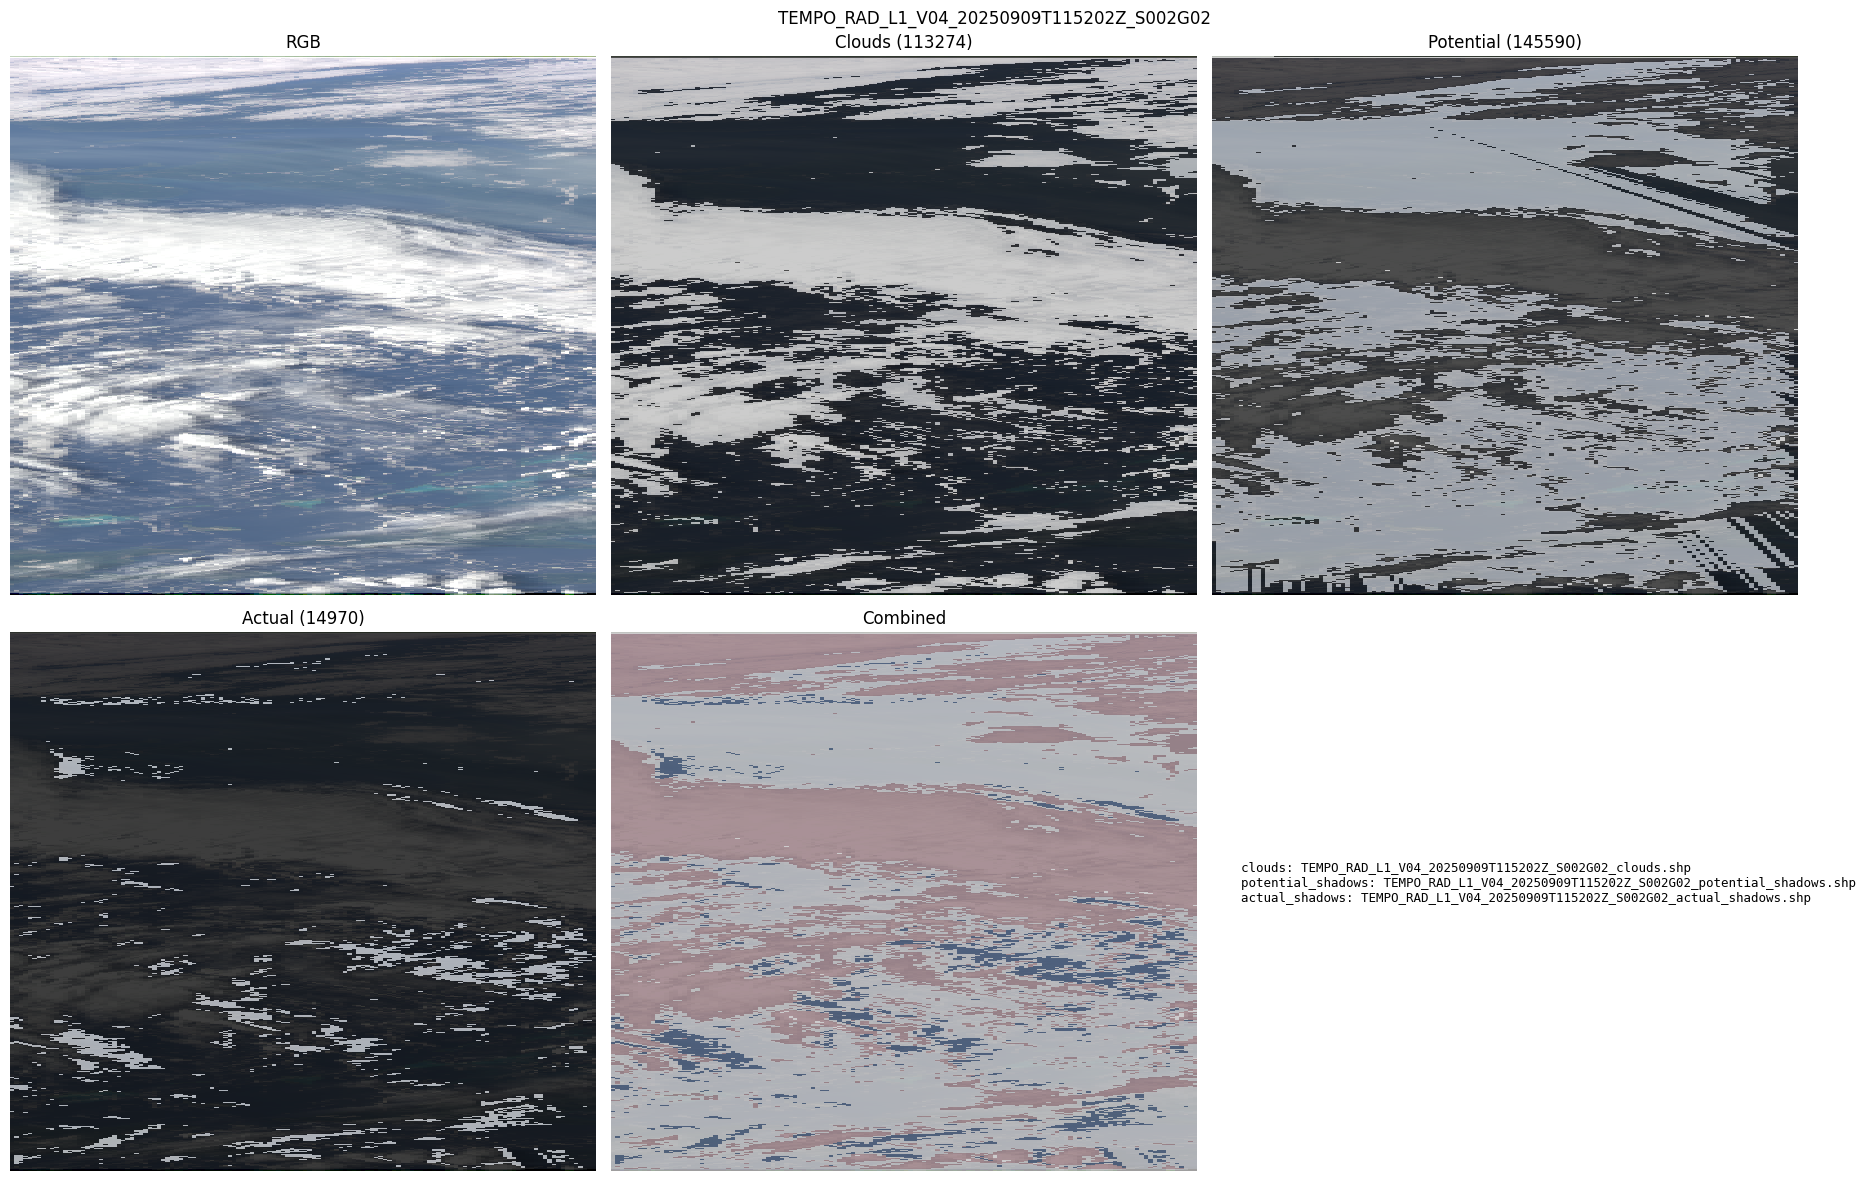


  2/4: TEMPO_RAD_L1_V04_20250909T115842Z_S002G03.nc
  Cloud fraction range: -999.000 to 1.000
  Processing 115139 cloud pixels...
    Progress: 0/115139
    Progress: 1000/115139
    Progress: 2000/115139
    Progress: 3000/115139
    Progress: 4000/115139
    Progress: 5000/115139
    Progress: 6000/115139
    Progress: 7000/115139
    Progress: 8000/115139
    Progress: 9000/115139
    Progress: 10000/115139
    Progress: 11000/115139
    Progress: 12000/115139
    Progress: 13000/115139
    Progress: 14000/115139
    Progress: 15000/115139
    Progress: 16000/115139
    Progress: 17000/115139
    Progress: 18000/115139
    Progress: 19000/115139
    Progress: 20000/115139
    Progress: 21000/115139
    Progress: 22000/115139
    Progress: 23000/115139
    Progress: 24000/115139
    Progress: 25000/115139
    Progress: 26000/115139
    Progress: 27000/115139
    Progress: 28000/115139
    Progress: 29000/115139
    Progress: 30000/115139
    Progress: 31000/115139
    Progress: 3200

/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/316731044.py:158: RuntimeWarning:

  Visualization: ../experiments/output_v2_height_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T115842Z_S002G03_visualization.png


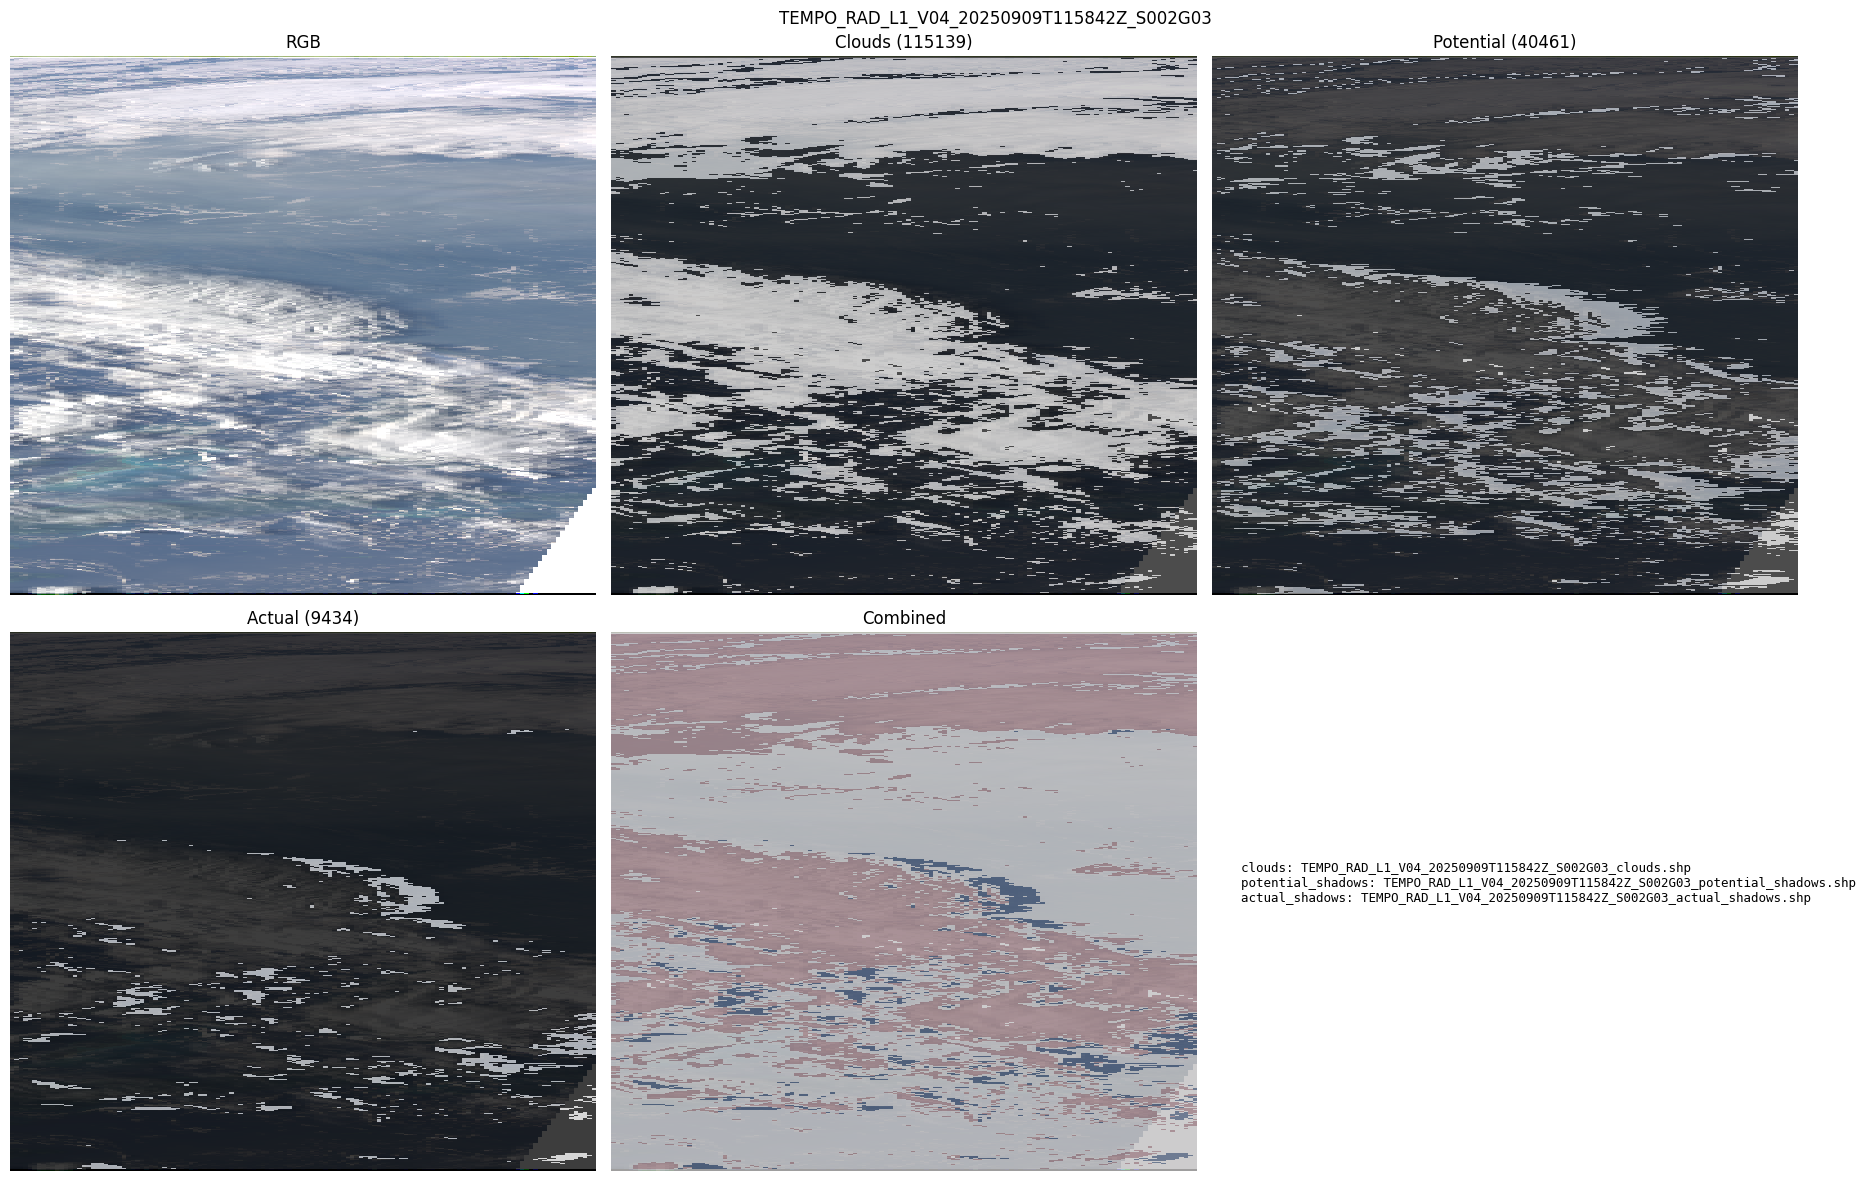


  3/4: TEMPO_RAD_L1_V04_20250909T125205Z_S003G05.nc
  Cloud fraction range: -999.000 to 1.000
  Processing 104962 cloud pixels...
    Progress: 0/104962
    Progress: 1000/104962
    Progress: 2000/104962
    Progress: 3000/104962
    Progress: 4000/104962
    Progress: 5000/104962
    Progress: 6000/104962
    Progress: 7000/104962
    Progress: 8000/104962
    Progress: 9000/104962
    Progress: 10000/104962
    Progress: 11000/104962
    Progress: 12000/104962
    Progress: 13000/104962
    Progress: 14000/104962
    Progress: 15000/104962
    Progress: 16000/104962
    Progress: 17000/104962
    Progress: 18000/104962
    Progress: 19000/104962
    Progress: 20000/104962
    Progress: 21000/104962
    Progress: 22000/104962
    Progress: 23000/104962
    Progress: 24000/104962
    Progress: 25000/104962
    Progress: 26000/104962
    Progress: 27000/104962
    Progress: 28000/104962
    Progress: 29000/104962
    Progress: 30000/104962
    Progress: 31000/104962
    Progress: 3200

/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/316731044.py:158: RuntimeWarning:

  Visualization: ../experiments/output_v2_height_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T125205Z_S003G05_visualization.png


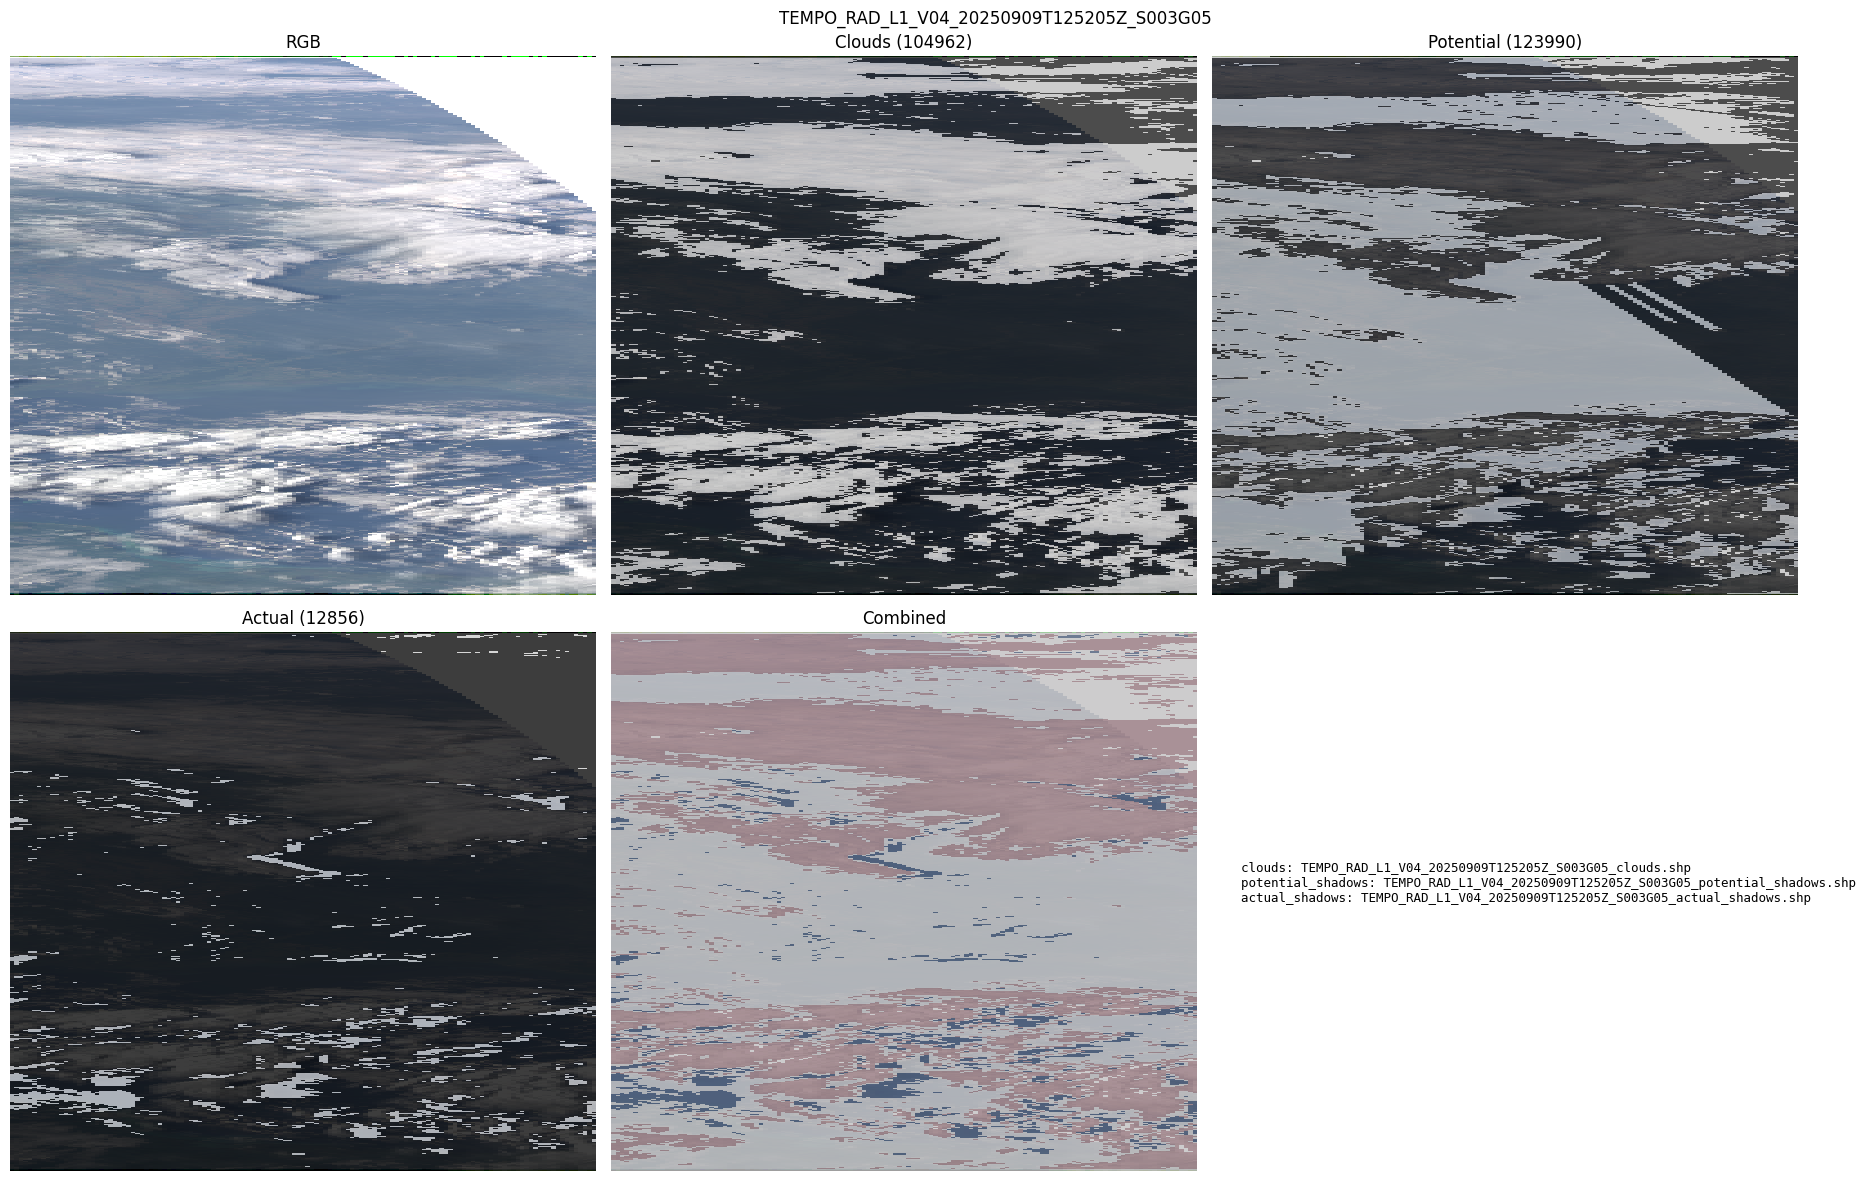


  4/4: TEMPO_RAD_L1_V04_20250909T231218Z_S014G02.nc
  Cloud fraction range: -999.000 to 1.000
  Processing 92207 cloud pixels...
    Progress: 0/92207
    Progress: 1000/92207
    Progress: 2000/92207
    Progress: 3000/92207
    Progress: 4000/92207
    Progress: 5000/92207
    Progress: 6000/92207
    Progress: 7000/92207
    Progress: 8000/92207
    Progress: 9000/92207
    Progress: 10000/92207
    Progress: 11000/92207
    Progress: 12000/92207
    Progress: 13000/92207
    Progress: 14000/92207
    Progress: 15000/92207
    Progress: 16000/92207
    Progress: 17000/92207
    Progress: 18000/92207
    Progress: 19000/92207
    Progress: 20000/92207
    Progress: 21000/92207
    Progress: 22000/92207
    Progress: 23000/92207
    Progress: 24000/92207
    Progress: 25000/92207
    Progress: 26000/92207
    Progress: 27000/92207
    Progress: 28000/92207
    Progress: 29000/92207
    Progress: 30000/92207
    Progress: 31000/92207
    Progress: 32000/92207
    Progress: 33000/92207

/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/967298460.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_2479/316731044.py:158: RuntimeWarning:

    Actual Shadow: 1070 polygons -> ../experiments/output_v2_height_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T231218Z_S014G02_actual_shadows.shp
  Visualization: ../experiments/output_v2_height_cthres0.3_helen_st0.05/TEMPO_RAD_L1_V04_20250909T231218Z_S014G02_visualization.png


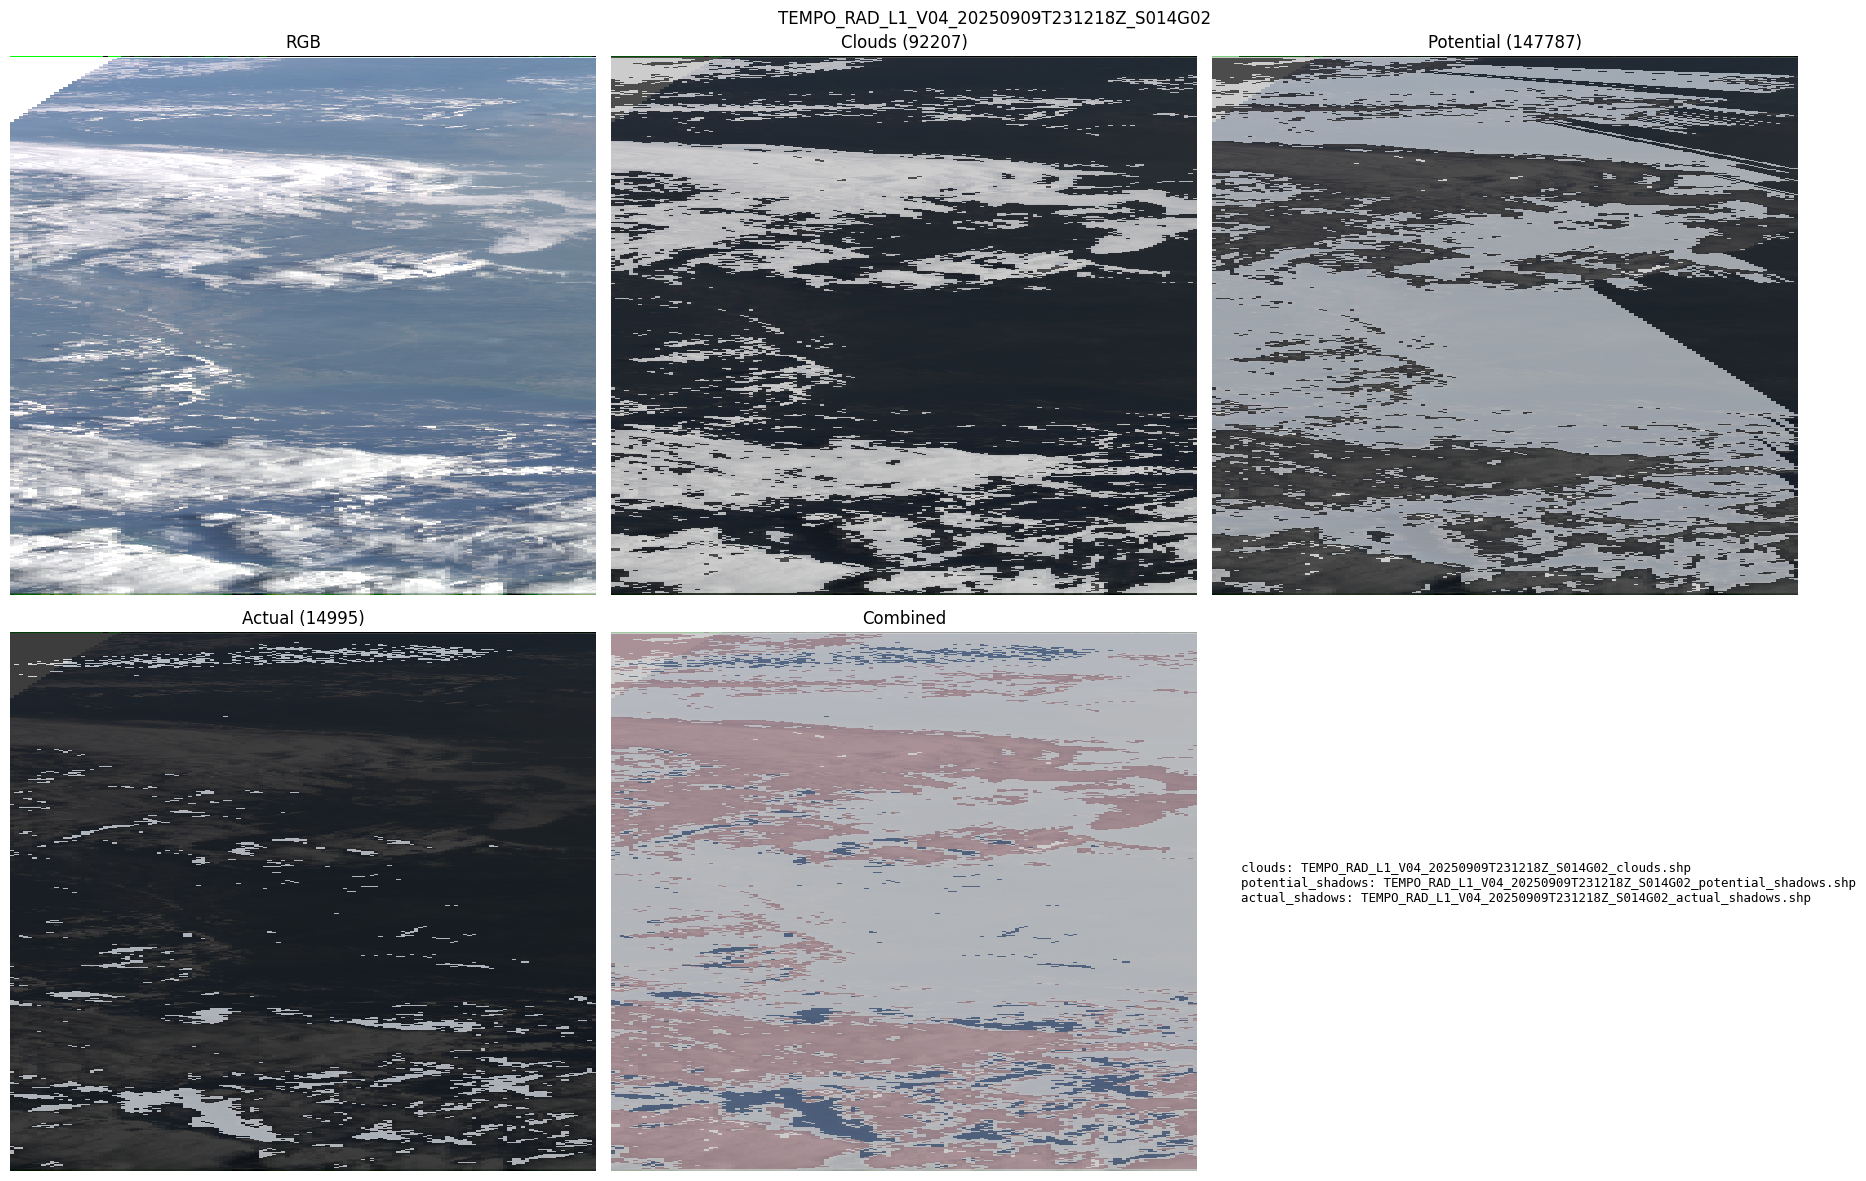

In [6]:
results = create_shadow_detection_pipeline_with_shapefiles(
    nc_files,
    l2_files,
    output_dir=output_dir,
    band=band,
    refinement=refinement,
    cloud_threshold=cloud_threshold,
    shadow_threshold=shadow_threshold,
    apply_gamma=True,
)